In [1]:
import tensorflow as tf
import keras
import numpy as np
import sys
import matplotlib.pyplot as plt

sys.path.append("../")

In [2]:
DATA_DIR = "../mu3e_trigger_data"
SIGNAL_PIXEL_FILE = f"{DATA_DIR}/sig_pixel_spacetime.npy"
BACKGROUND_PIXEL_FILE = f"{DATA_DIR}/bg_pixel_spacetime.npy"
SIGNAL_MPPC_FILE = f"{DATA_DIR}/sig_mppc_spacetime.npy"
BACKGROUND_MPPC_FILE = f"{DATA_DIR}/bg_mppc_spacetime.npy"
SIGNAL_ONLY_PIXEL_FILE = f"{DATA_DIR}/sig_only_pixel_spacetime.npy"
SIGNAL_ONLY_MPPC_FILE = f"{DATA_DIR}/sig_only_mppc_spacetime.npy"


bg_pixel_spacetime = np.load(BACKGROUND_PIXEL_FILE)
bg_mppc_spacetime = np.load(BACKGROUND_MPPC_FILE)
sig_pixel_spacetime = np.load(SIGNAL_PIXEL_FILE)
sig_mppc_spacetime = np.load(SIGNAL_MPPC_FILE)

from sklearn.preprocessing import StandardScaler

input_seq_len = bg_pixel_spacetime.shape[1]
input_dim = bg_pixel_spacetime.shape[2]  # Exclude timestamp

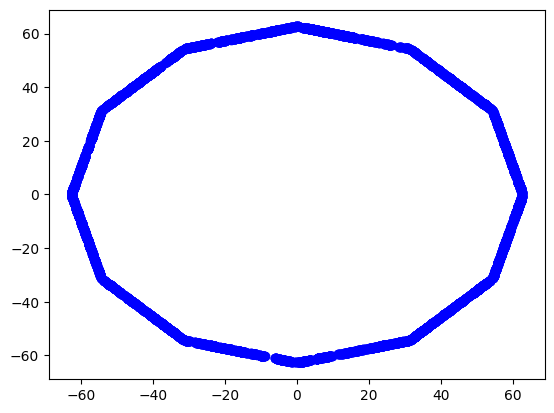

In [3]:
plt.scatter(bg_mppc_spacetime[:100, :, 0][bg_mppc_spacetime[:100, :, 0] != -1], bg_mppc_spacetime[:100, :, 1][bg_mppc_spacetime[:100, :, 1] != -1], color = "blue")
plt.show()

In [4]:
pixel_input = keras.Input(shape=(input_seq_len, input_dim), name="pixel_input")
mppc_input = keras.Input(shape=(input_seq_len, input_dim), name="mppc_input")

In [5]:
from src.model.components import (
    MultiHeadAttentionStack,
    MultiHeadAttentionBlock,
    SelfAttentionStack,
    SelfAttentionBlock,
    PoolingAttentionBlock,
    GenerateMask,
    MLP,
)

feature_dim = 8
num_heads = 4
dropout_rate = 0

pixel_mask = GenerateMask(name="mask")(pixel_input)
pixel_embedding = MLP(
    num_layers=4,
    output_dim=feature_dim,
    activation="relu",
    name="input_embedding",
    dropout_rate=dropout_rate,
)(pixel_input)

pixel_self_attention = MultiHeadAttentionStack(
    num_heads=num_heads,
    key_dim=feature_dim,
    stack_size = 3,
    name="self_attention",
    dropout_rate=dropout_rate,
    self_attention=True,
    pre_ln=True,
)(pixel_embedding,pixel_embedding , query_mask = pixel_mask, value_mask=pixel_mask)
pixel_pooling = PoolingAttentionBlock(
    num_seeds = 1,
    key_dim=feature_dim,
    name="pooling_attention",
    dropout_rate=dropout_rate,
)(pixel_self_attention, mask=pixel_mask)

mppc_mask = GenerateMask(name="mppc_mask")(mppc_input)
mppc_embedding = MLP(
    num_layers=4,
    output_dim=feature_dim,
    activation="relu",
    name="mppc_embedding",
    dropout_rate=dropout_rate,
)(mppc_input)
mppc_self_attention = MultiHeadAttentionStack(
    num_heads=num_heads,
    key_dim=feature_dim,
    stack_size = 3,
    name="mppc_self_attention",
    dropout_rate=dropout_rate,
    self_attention=True,
    pre_ln=True,
)(mppc_embedding,mppc_embedding , query_mask = mppc_mask, value_mask=mppc_mask)
mppc_pooling = PoolingAttentionBlock(
    num_seeds = 1,
    key_dim=feature_dim,
    name="mppc_pooling_attention",
    dropout_rate=dropout_rate,
)(mppc_self_attention, mask=mppc_mask)


latent_space = keras.layers.Concatenate(name="latent_space")([pixel_pooling, mppc_pooling])
latent_space = keras.layers.Flatten(name="flatten")(latent_space)
output = MLP(
    num_layers=4,
    output_dim=1,
    activation="sigmoid",
    name="output",
    dropout_rate=dropout_rate,
)(latent_space)

model = keras.Model(
    inputs=[pixel_input, mppc_input],
    outputs=output,
    name="ClassificationModel",
)
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.BinaryAccuracy()],
)

/Users/simi/mu3e_trigger/venv/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'pooling_attention' (of type PoolingAttentionBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/Users/simi/mu3e_trigger/venv/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'mppc_pooling_attention' (of type PoolingAttentionBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [6]:
model.summary()

Model: "ClassificationModel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ pixel_input         │ (None, 128, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mppc_input          │ (None, 128, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_embedding     │ (None, 128, 8)    │        137 │ pixel_input[0][0] │
│ (MLP)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask (GenerateMask) │ (None, 128, 1)    │          0 │ pixel_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mppc_embedding      │ (None, 128, 8)    │        137 │ mppc_input[0][0]  │
│ (MLP)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mppc_mask           │ (None, 128, 1)    │          0 │ mppc_input[0][0]  │
│ (GenerateMask)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention      │ (None, 128, 8)    │      5,136 │ input_embedding[… │
│ (MultiHeadAttentio… │                   │            │ input_embedding[… │
│                     │                   │            │ mask[0][0],       │
│                     │                   │            │ mask[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mppc_self_attention │ (None, 128, 8)    │      5,136 │ mppc_embedding[0… │
│ (MultiHeadAttentio… │                   │            │ mppc_embedding[0… │
│                     │                   │            │ mppc_mask[0][0],  │
│                     │                   │            │ mppc_mask[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pooling_attention   │ (None, 1, 8)      │      2,016 │ self_attention[0… │
│ (PoolingAttentionB… │                   │            │ mask[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mppc_pooling_atten… │ (None, 1, 8)      │      2,016 │ mppc_self_attent… │
│ (PoolingAttentionB… │                   │            │ mppc_mask[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent_space        │ (None, 1, 16)     │          0 │ pooling_attentio… │
│ (Concatenate)       │                   │            │ mppc_pooling_att… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16)        │          0 │ latent_space[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (MLP)        │ (None, 1)         │        185 │ flatten[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,763 (57.67 KB)

 Trainable params: 14,763 (57.67 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
from sklearn.model_selection import train_test_split

(
    X_pixel_train,
    X_pixel_test,
    X_mppc_train,
    X_mppc_test,
    y_train,
    y_test,
) = train_test_split(
    np.concatenate([bg_pixel_spacetime[:, :, :], sig_pixel_spacetime[:, :, :]], axis=0),
    np.concatenate([bg_mppc_spacetime[:, :, :], sig_mppc_spacetime[:, :, :]], axis=0),
    np.concatenate(
        [np.zeros(len(bg_pixel_spacetime)), np.ones(len(sig_pixel_spacetime))]
    ),
    test_size=0.2,
    random_state=42,
    shuffle=True,
)


In [ ]:
model.fit(
    x=[X_pixel_train, X_mppc_train],
    y=y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=512,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=10, restore_best_weights=True
        )
    ],
    class_weight = {label: 1/np.mean(y_train == label) for label in np.unique(y_train)}
)

Epoch 1/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - binary_accuracy: 0.5569 - loss: 1.3832 - val_binary_accuracy: 0.5663 - val_loss: 0.6823
Epoch 2/100
120/174 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - binary_accuracy: 0.5613 - loss: 1.3710

In [ ]:
test_seq_length = (X_pixel_test != -1).all(axis=-1).sum(axis=-1) + (X_mppc_test != -1).all(
    axis=-1
).sum(axis=-1)
test_mppc_length = (X_mppc_test != -1).all(axis=-1).sum(axis=-1)
test_pixel_length = (X_pixel_test != -1).all(axis=-1).sum(axis=-1)
train_mppc_length = (X_mppc_train != -1).all(axis=-1).sum(axis=-1)
train_pixel_length = (X_pixel_train != -1).all(axis=-1).sum(axis=-1)

In [ ]:
mppc_lenght_input = keras.Input(shape=(1,), name="mppc_length_input")
pixel_length_input = keras.Input(shape=(1,), name="pixel_length_input")

input = keras.layers.Concatenate(name="input")(
    [
        mppc_lenght_input,
        pixel_length_input,
    ]
)
encoder = MLP(
    num_layers=3,
    output_dim=10,
    name="encoder",
    activation="relu",
)(input)
decoder = MLP(
    num_layers=3,
    output_dim=1,
    name="decoder",
    activation="sigmoid",
)(encoder)
seq_length_mlp = keras.Model(
    inputs=[mppc_lenght_input, pixel_length_input],
    outputs=decoder,
    name="SeqLengthMLP",
)

In [ ]:
seq_length_mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.BinaryAccuracy()],
)
seq_length_mlp.summary()

In [ ]:
seq_length_mlp.fit(
    x=[train_mppc_length, train_pixel_length],
    y=y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=128,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=10, restore_best_weights=True
        )
    ],
    class_weight={label: np.sum(y_train == label) / len(y_train) for label in np.unique(y_train) if label in [0, 1]}
)

In [ ]:
test_predictions = model.predict([X_pixel_test, X_mppc_test])
test_seq_length = seq_length_mlp.predict([test_mppc_length, test_pixel_length])

from sklearn.metrics import confusion_matrix, roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, test_predictions)
fpr_seq_length, tpr_seq_length, thresholds_seq_length = roc_curve(y_test, test_seq_length)
roc_auc_seq_length = auc(fpr_seq_length, tpr_seq_length)
roc_auc = auc(fpr, tpr)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="blue", label="ROC curve (area = {:.2f})".format(roc_auc))
plt.plot(
    fpr_seq_length,
    tpr_seq_length,
    color="green",
    label="MLP trained on number of hits of MPPC and Pixels (area = {:.2f})".format(roc_auc_seq_length),
)
plt.title("Signal only")
plt.grid()
plt.plot([0, 1], [0, 1], color="red", linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.savefig("roc_curve.png")